In [26]:
import pyBigWig
import numpy as np

cp = pyBigWig.open("../outputs/3E/ctcf.cleavageprop.bw")
wps = pyBigWig.open("../outputs/3E/ctcf.wps.bw")

In [36]:
counter = 0
cp_vals = []
wps_vals = []
count = 0

with open('../data/ctcf.hg19.bed', 'rt') as ctcf:
    for line in ctcf:
        chrom, start, end, _, _, strand = line.strip().split('\t')
        position = (int(start) + int(end))//2
        chrom = chrom[3:]
        try:
            cp_val = cp.values(chrom, position-2000, position+2001)
            wps_val = wps.values(chrom, position-2000, position+2001)
            if strand=='+':
                cp_vals.append(cp_val)
                wps_vals.append(wps_val)
            elif strand=="-":
                cp_vals.append(list(reversed(cp_val)))
                wps_vals.append(list(reversed(wps_val)))
            count += 1
        except RuntimeError as e:
            counter += 1

if count > 0:
    cp_vals = np.array(cp_vals)
    wps_vals = np.array(wps_vals)
    
    avg_cp_val = np.nanmean(cp_vals, axis=0).tolist()
    avg_wps_val = np.nanmean(wps_vals, axis=0).tolist()


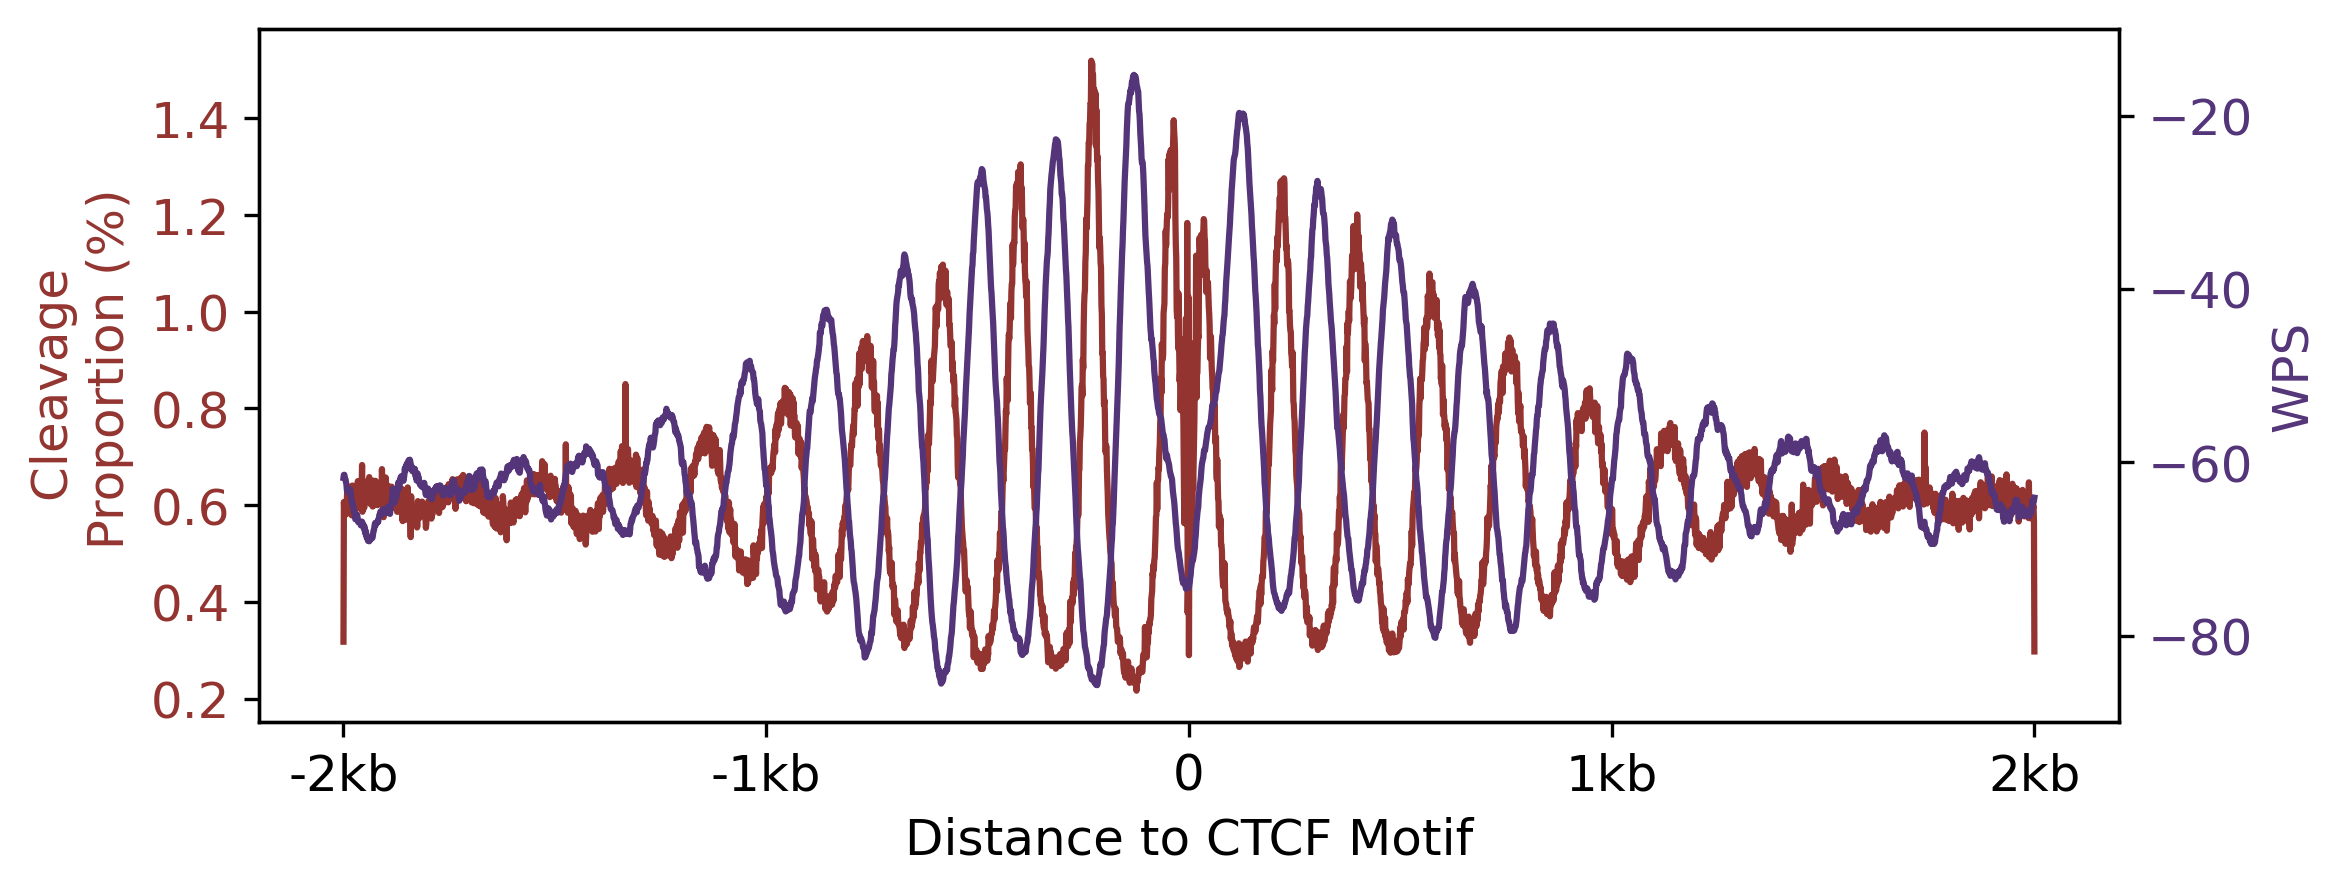

In [74]:
import matplotlib.pyplot as plt
import numpy as np

positions = range(len(avg_cp_val))

# Create the plot
fig, ax1 = plt.subplots(figsize=(8, 3), dpi=300)

# Plot avg_cp_val on the left y-axis
ax1.plot(positions, avg_cp_val, label='Average cp_val', color='#933430')
ax1.set_xlabel('Distance to CTCF Motif', fontsize=12)
ax1.set_ylabel('Cleavage \n Proportion (%)', color='#933430', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#933430', labelsize=12)

# Adjust x-ticks for -2kb to 2kb
ax1.set_xticks([0, len(avg_cp_val)//4, len(avg_cp_val)//2, 3*len(avg_cp_val)//4, len(avg_cp_val)-1])
ax1.set_xticklabels(['-2kb', '-1kb', '0', '1kb', '2kb'], fontsize=12)

# Set y-ticks for cp_val (from 0.2 to 1.4 in 0.2 increments)
ax1.set_yticks(np.arange(0.2, 1.5, 0.2))
ax1.tick_params(axis='y', labelcolor='#933430', labelsize=12)
# Create a second y-axis for avg_wps_val
ax2 = ax1.twinx()
ax2.plot(positions, avg_wps_val, label='Average wps_val', color='#543579')
ax2.set_ylabel('WPS', color='#543579', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#543579', labelsize=12)
ax2.set_ylim(-90, -10)
ax2.set_yticks(np.arange(-20, -100, -20))
ax2.tick_params(axis='y', labelcolor='#543579', labelsize=12)

# Show the plot
plt.show()
